In [30]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [31]:
manual_df = pd.read_csv("data/clean_sample_agent_repos_withShortReadme_manual.csv")
deepseek_df = pd.read_csv("data/sample_agent_repos_llm_filtered_withShortReadme_DeepSeekR1.csv")

In [32]:
assert len(manual_df) == len(deepseek_df), "CSV files must have same number of rows"

In [33]:
manual_df.head(3)

,full_name,description,stars,forks,language,url,updated_year,last_updated,created_year,created_at,...,size,license,languages,primary_language,topics,readme_snippet,Manual,Comment,Unnamed: 20,manual_normalized
0,chrisjcc/llm-applied-research,Research and development framework for large l...,0,0,Python,https://github.com/chrisjcc/llm-applied-research,2025,2025-10-02T00:18:15+00:00,2025,2025-09-23T15:05:14+00:00,...,301,Apache License 2.0,"{'Python': 65791, 'Shell': 2297}",Python,[],llm-applied-research Research and development ...,agentic framework,It has less information in its readme,NaN,other
1,RoshanM24/Langgraph-with-Astra-DB---Multi-Sour...,This project demonstrates the integration of L...,1,0,Python,https://github.com/RoshanM24/Langgraph-with-As...,2025,2025-08-13T00:07:51+00:00,2025,2025-08-12T23:24:58+00:00,...,12,NaN,{'Python': 7957},Python,[],LangGraph with Astra DB — Intelligent Query Ro...,LLM-Based agentic system,NaN,NaN,llm-based agentic system
2,karaalv/portfolio-agent,RAG based portfolio chat agent 🤖,0,0,Python,https://github.com/karaalv/portfolio-agent,2025,2025-08-31T17:49:06+00:00,2025,2025-07-28T22:28:51+00:00,...,204,Apache License 2.0,"{'Python': 169011, 'HCL': 14250, 'Shell': 4827...",Python,"['ai', 'llm', 'portfolio-website', 'rag-chatbot']",Portfolio Agent 🤖 The agent can also email the...,LLM-Based agentic system,Less readme is copied,NaN,llm-based agentic system


In [34]:

deepseek_df.head(3)

,full_name,description,stars,forks,language,url,updated_year,last_updated,created_year,created_at,watchers_count,size,license,languages,primary_language,topics,readme_snippet,category
0,chrisjcc/llm-applied-research,Research and development framework for large l...,0,0,Python,https://github.com/chrisjcc/llm-applied-research,2025,2025-10-02T00:18:15+00:00,2025,2025-09-23T15:05:14+00:00,0,301,Apache License 2.0,"{'Python': 65791, 'Shell': 2297}",Python,[],llm-applied-research Research and development ...,other
1,RoshanM24/Langgraph-with-Astra-DB---Multi-Sour...,This project demonstrates the integration of L...,1,0,Python,https://github.com/RoshanM24/Langgraph-with-As...,2025,2025-08-13T00:07:51+00:00,2025,2025-08-12T23:24:58+00:00,1,12,NaN,{'Python': 7957},Python,[],LangGraph with Astra DB — Intelligent Query Ro...,other
2,karaalv/portfolio-agent,RAG based portfolio chat agent 🤖,0,0,Python,https://github.com/karaalv/portfolio-agent,2025,2025-08-31T17:49:06+00:00,2025,2025-07-28T22:28:51+00:00,0,204,Apache License 2.0,"{'Python': 169011, 'HCL': 14250, 'Shell': 4827...",Python,"['ai', 'llm', 'portfolio-website', 'rag-chatbot']",Portfolio Agent 🤖 The agent can also email the...,llm-based agentic system


In [35]:
y_true = manual_df["manual_normalized"]
y_pred = deepseek_df["category"]

In [36]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n===== {model_name} Evaluation =====")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return accuracy, precision, recall, f1

In [37]:
deepseek_acc, deepseek_prec, deepseek_rec, deepseek_f1 = evaluate_model(y_true, y_pred, "DeepSeekR1")


===== DeepSeekR1 Evaluation =====
Accuracy:  0.7143
Precision: 0.7081
Recall:    0.6904
F1-score:  0.6941

Detailed Report:
                          precision    recall  f1-score   support

llm-based agentic system       0.73      0.83      0.77       103
                   other       0.69      0.56      0.62        72

                accuracy                           0.71       175
               macro avg       0.71      0.69      0.69       175
            weighted avg       0.71      0.71      0.71       175



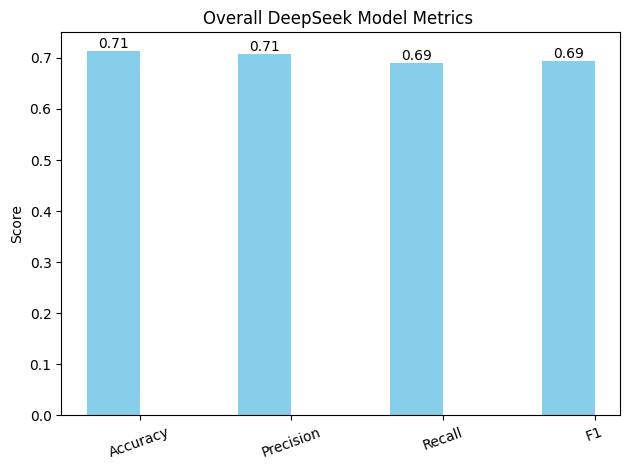

In [39]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

deepseek_scores = [deepseek_acc, deepseek_prec, deepseek_rec, deepseek_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
bars1 = plt.bar(x - width/2, deepseek_scores, width, label="DeepSeekR1", color="skyblue")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Overall DeepSeek Model Metrics ")

# 🔹 Add values above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [40]:
comparison_df = manual_df.copy()

# Add DeepSeek predictions
comparison_df["DeepSeek_Category"] = deepseek_df["category"]

# Mark correctness
comparison_df["DeepSeek_Correct"] = (
    comparison_df["manual_normalized"] == comparison_df["DeepSeek_Category"]
)

# Mark wrong predictions
comparison_df["DeepSeek_Wrong"] = ~comparison_df["DeepSeek_Correct"]

# Rename column for clarity
comparison_df = comparison_df.rename(
    columns={"Manual": "Manual_Category"}
)

# Save results
comparison_df.to_csv(
    "data/sample_with_deepseek_manual_results_comparison.csv",
    index=False
)

print("\nSaved comparison to: sample_with_qwen_results_comparison.csv")


Saved comparison to: sample_with_qwen_results_comparison.csv


In [41]:
# Save only incorrect predictions
# ---------------------------------
incorrect_df = comparison_df[comparison_df["DeepSeek_Wrong"] == True]

print("Total incorrect predictions:", len(incorrect_df))

Total incorrect predictions: 50


In [42]:
incorrect_df.head(5)

,full_name,description,stars,forks,language,url,updated_year,last_updated,created_year,created_at,...,primary_language,topics,readme_snippet,Manual_Category,Comment,Unnamed: 20,manual_normalized,DeepSeek_Category,DeepSeek_Correct,DeepSeek_Wrong
1,RoshanM24/Langgraph-with-Astra-DB---Multi-Sour...,This project demonstrates the integration of L...,1,0,Python,https://github.com/RoshanM24/Langgraph-with-As...,2025,2025-08-13T00:07:51+00:00,2025,2025-08-12T23:24:58+00:00,...,Python,[],LangGraph with Astra DB — Intelligent Query Ro...,LLM-Based agentic system,NaN,NaN,llm-based agentic system,other,False,True
3,bhevin/Search-Engine-With-LLm-and-Agents,NaN,0,0,Python,https://github.com/bhevin/Search-Engine-With-L...,2024,2024-08-13T00:10:07+00:00,2024,2024-08-12T10:25:54+00:00,...,Python,[],Search-Engine-With-LLm-and-Agents,LLM-Based agentic system,NaN,NaN,llm-based agentic system,other,False,True
8,orcunyildiz/the-lit-digest,An LLM-powered agent that generates personaliz...,0,0,Python,https://github.com/orcunyildiz/the-lit-digest,2025,2025-10-13T17:27:41+00:00,2025,2025-10-13T16:18:08+00:00,...,Python,[],📚 Monthly Literature Recommender Agent This Py...,LLM-powered recommendation pipeline,NaN,NaN,other,llm-based agentic system,False,True
10,Migue8gl/RAG-Agent,A lightweight and modular Retrieval-Augmented ...,2,0,Python,https://github.com/Migue8gl/RAG-Agent,2025,2025-05-04T11:39:37+00:00,2025,2025-05-04T11:30:09+00:00,...,Python,"['agent', 'chunker', 'faiss', 'ia', 'langgraph...",RAG-Agent 🚀 RAG-Agent is a modular and efficie...,RAG application framework,NaN,NaN,other,llm-based agentic system,False,True
11,harshnegi1434/multi-pdf-chat-ai-agent,AI-powered app to chat with and search across ...,0,0,Python,https://github.com/harshnegi1434/multi-pdf-cha...,2025,2025-07-24T12:16:29+00:00,2025,2025-07-20T17:24:27+00:00,...,Python,"['aws-cloudfront', 'aws-lambda', 'fastapi', 'l...",InsightPDF: Multi-PDF Chat AI Agent InsightPDF...,LLM agent not llm based agentic systen,NaN,NaN,other,llm-based agentic system,False,True


In [43]:
incorrect_df.to_csv(
    "data/incorrect_predicted_sample_deepseek.csv",
    index=False
)